<a href="https://colab.research.google.com/github/Ajodo-Godson/automata_diags/blob/main/Automata_Diags_Backend_Playground.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automata Diags Backend Playground (Colab)

Use this notebook to quickly test and explore the `automata-diags` backend package.

Covers:
- DFA
- NFA
- CFG algorithms (acceptance, CYK, derivation)
- PDA
- Turing Machine
- Optional Graphviz visualizations

In [31]:
# Required install
!pip -q install automata-diags

## Imports

In [32]:
from automata import (
    create_dfa_from_table,
    AutomataDrawer,
    CFG,
    cyk_accept,
    accept_string,
    generate_strings,
    get_derivation,
    PDA,
    TuringMachine,
)
from automata.backend.grammar.regular_languages.nfa.nfa_mod import NFA

print("Imports successful.")

Imports successful.


## 1) DFA Example
Language: strings over `{0,1}` that end in `1`.

In [33]:
dfa_table = {
    "q0": {"0": "q0", "1": "q1"},
    "q1": {"0": "q0", "1": "q1"},
}

dfa = create_dfa_from_table(
    table=dfa_table,
    start_state="q0",
    accept_states={"q1"},
)

tests = ["", "0", "1", "1010", "1011", "111"]
for w in tests:
    print(f"{w!r:>6} -> {dfa.accepts(w)}")

    '' -> False
   '0' -> False
   '1' -> True
'1010' -> False
'1011' -> True
 '111' -> True


## 2) NFA Example
Build an NFA from transition string format.

In [34]:
# This NFA accepts strings ending with "ab"
nfa_string = "q0,a,q0,q1; q0,b,q0; q1,b,q2"
nfa = NFA.from_string(
    nfa_string=nfa_string,
    start_state="q0",
    accept_states={"q2"},
)

tests = ["", "a", "ab", "babab", "abba", "aaab"]
for w in tests:
    print(f"{w!r:>6} -> {nfa.accepts(w)}")

    '' -> False
   'a' -> False
  'ab' -> True
'babab' -> True
'abba' -> False
'aaab' -> True


## 3) CFG Example
Grammar for balanced parentheses over terminals `(` and `)`:

- `S -> S S | ( S ) | ε`

Note: tokens are space-separated in `CFG.from_string`.

In [35]:
grammar_str = """
S -> S S | ( S ) | ε
"""

cfg = CFG.from_string(grammar_str)

tests = ["", "()", "(())", "()()", "(()", ")("]
print("General CFG acceptance:")
for w in tests:
    print(f"{w!r:>6} -> {accept_string(cfg, w)}")

cfg_cnf = cfg.to_cnf()
print("\nCYK (on CNF grammar):")
for w in tests:
    print(f"{w!r:>6} -> {cyk_accept(cfg_cnf, w)}")

target = "()()"
print("\nOne derivation for", repr(target), ":")
print(get_derivation(cfg, target))


General CFG acceptance:
    '' -> True
  '()' -> True
'(())' -> True
'()()' -> True
 '(()' -> False
  ')(' -> False

CYK (on CNF grammar):
    '' -> False
  '()' -> True
'(())' -> True
'()()' -> True
 '(()' -> False
  ')(' -> False

One derivation for '()()' :
['S', 'SS', 'S(S)', 'S()', '(S)()', '()()']


## 4) PDA Example
Classic PDA for language `a^n b^n` (with `n >= 1`).

In [36]:
pda_string = (
    "q0,a,Z,q0,aZ; "
    "q0,a,a,q0,aa; "
    "q0,b,a,q1,e; "
    "q1,b,a,q1,e; "
    "q1,e,Z,q2,Z"
)

pda = PDA.from_string(
    pda_string=pda_string,
    start_state="q0",
    accept_states={"q2"},
    start_stack_symbol="Z",
)

tests = ["ab", "aabb", "aaabbb", "aab", "abb", ""]
for w in tests:
    print(f"{w!r:>8} -> {pda.accepts(w)}")

word = "aabb"
trace = pda.get_configuration_trace(word)
print(f"\nTrace for {word!r} (state, index, stack):")
print(trace)

    'ab' -> True
  'aabb' -> True
'aaabbb' -> True
   'aab' -> False
   'abb' -> False
      '' -> False

Trace for 'aabb' (state, index, stack):
[('q0', 0, ('Z',)), ('q0', 1, ('Z', 'a')), ('q0', 2, ('Z', 'a', 'a')), ('q1', 3, ('Z', 'a')), ('q1', 4, ('Z',)), ('q2', 4, ('Z',))]


## 5) Turing Machine Example
TM that accepts binary strings ending in `1`.

In [37]:
tm_string = (
    "q0,0,q0,0,R; "
    "q0,1,q0,1,R; "
    "q0,_,q1,_,L; "
    "q1,1,qa,1,N"
)

tm = TuringMachine.from_string(
    tm_string=tm_string,
    start_state="q0",
    accept_states={"qa"},
    blank_symbol="_",
)

tests = ["", "0", "1", "1010", "1011", "111"]
for w in tests:
    try:
        result = tm.accepts(w)
    except Exception as e:
        result = f"Error: {e}"
    print(f"{w!r:>6} -> {result}")

    '' -> False
   '0' -> False
   '1' -> True
'1010' -> False
'1011' -> True
 '111' -> True


## 6) Optional Visualization (Graphviz)
Colab may need system Graphviz (`dot`) installed.

In [38]:
# Optional: install system graphviz for rendering images
!apt-get -qq update
!apt-get -qq install -y graphviz

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Saved: outputs/dfa_ends_in_1.png


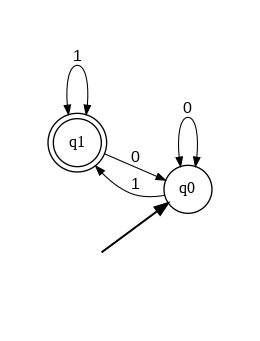

In [39]:
from IPython.display import Image, display

drawer = AutomataDrawer(output_dir="outputs")
img_path = drawer.draw_dfa(
    transitions=dfa_table,
    start_state="q0",
    accept_states={"q1"},
    filename="dfa_ends_in_1",
    format="png",
)
print("Saved:", img_path)
display(Image(filename=img_path))

## 7) Quick Playground Cell
Edit `word` and rerun.

In [40]:
word = "1011"
print("DFA accepts:", dfa.accepts(word))
print("NFA accepts:", nfa.accepts(word))
print("TM accepts :", tm.accepts(word))

DFA accepts: True
NFA accepts: False
TM accepts : True


## 8) Advanced Labs

These are deeper backend workflows beyond basic acceptance checks.

- Conversion/equivalence style testing
- Grammar-to-automaton compilation
- Transducers (input -> output symbols)
- Multi-tape Turing machine behavior

In [41]:
# Advanced imports (internal modules)
from automata.backend.grammar.dist import (
    State,
    Symbol,
    TapeSymbol,
    StateSet,
    Alphabet,
    TapeAlphabet,
    OutputAlphabet,
)
from automata.backend.grammar.transducers.mealy_machine import MealyMachine
from automata.backend.grammar.turing_machines.multitape import MultiTapeTuringMachine

print("Advanced imports loaded.")

Advanced imports loaded.


In [42]:
# Advanced A: NFA -> DFA equivalence spot check on a test suite
nfa2_string = "q0,a,q0,q1; q0,b,q0; q1,b,q2"
nfa2 = NFA.from_string(nfa_string=nfa2_string, start_state="q0", accept_states={"q2"})
dfa2 = nfa2.to_dfa()

sample_words = [
    "",
    "a",
    "b",
    "ab",
    "aab",
    "babab",
    "abb",
    "baab",
    "aaaaab",
]

print("word | NFA | DFA")
print("-" * 24)
for w in sample_words:
    nfa_ans = nfa2.accepts(w)
    dfa_ans = dfa2.accepts(w)
    print(f"{w!r:8} {str(nfa_ans):5} {str(dfa_ans):5}")

print("\nEquivalent on sample suite:", all(nfa2.accepts(w) == dfa2.accepts(w) for w in sample_words))

word | NFA | DFA
------------------------
''       False False
'a'      False False
'b'      False False
'ab'     True  True 
'aab'    True  True 
'babab'  True  True 
'abb'    False False
'baab'   True  True 
'aaaaab' True  True 

Equivalent on sample suite: True


In [43]:
# Advanced B: Compile CFG -> PDA and test acceptance consistency
cfg2 = CFG.from_string("""
S -> a S b | ε
""")

pda_from_cfg = PDA.from_cfg(cfg2)

words = ["", "ab", "aabb", "aaabbb", "aab", "abb", "bbaa"]
print("word | CFG_accept | PDA_from_CFG_accept")
print("-" * 42)
for w in words:
    cfg_ok = accept_string(cfg2, w)
    pda_ok = pda_from_cfg.accepts(w)
    print(f"{w!r:8} {str(cfg_ok):10} {str(pda_ok):18}")

trace_word = "aabb"
trace = pda_from_cfg.get_configuration_trace(trace_word)
print(f"\nTrace length for {trace_word!r}:", 0 if trace is None else len(trace))
print("First few configs:", None if trace is None else trace[:6])

word | CFG_accept | PDA_from_CFG_accept
------------------------------------------
''       True       True              
'ab'     True       True              
'aabb'   True       True              
'aaabbb' True       True              
'aab'    False      False             
'abb'    False      False             
'bbaa'   False      False             

Trace length for 'aabb': 10
First few configs: [('q_start', 0, ('Z',)), ('q_loop', 0, ('Z', 'S')), ('q_loop', 0, ('Z', 'b', 'S', 'a')), ('q_loop', 1, ('Z', 'b', 'S')), ('q_loop', 1, ('Z', 'b', 'b', 'S', 'a')), ('q_loop', 2, ('Z', 'b', 'b', 'S'))]


In [44]:
# Advanced C: Mealy machine transducer (running parity encoder)
# Output symbol at each step indicates parity of 1s seen so far: E or O

states = StateSet.from_states({State("E"), State("O")})
input_alpha = Alphabet(["0", "1"])
output_alpha = OutputAlphabet(["E", "O"])

transitions = {
    State("E"): {Symbol("0"): State("E"), Symbol("1"): State("O")},
    State("O"): {Symbol("0"): State("O"), Symbol("1"): State("E")},
}

output_function = {
    State("E"): {Symbol("0"): Symbol("E"), Symbol("1"): Symbol("O")},
    State("O"): {Symbol("0"): Symbol("O"), Symbol("1"): Symbol("E")},
}

mealy = MealyMachine(
    states=states,
    input_alphabet=input_alpha,
    output_alphabet=output_alpha,
    transitions=transitions,
    output_function=output_function,
    start_state=State("E"),
)

inp = "101101"
out = mealy.transduce(inp)
print("input :", inp)
print("output:", "".join(out))

input : 101101
output: OOEOOE


## 9) Integrated Advanced Project: Cross-Model Equivalence

This section implements **the same language** with many computational models and verifies that they agree.

Target language:

\[
L = \{ w \in \{0,1\}^* \mid w \text{ ends with } 1 \}
\]

Models used:
- DFA
- NFA
- CFG + general derivation acceptance
- PDA compiled from CFG
- Single-tape Turing machine
- Multi-tape Turing machine
- Multi-head Turing machine

Next, we run exhaustive tests and compare all outputs.

In [45]:
# Build one recognizer per model for L = strings ending in '1'
from itertools import product

# ----- DFA -----
cap_dfa_table = {
    "q0": {"0": "q0", "1": "q1"},
    "q1": {"0": "q0", "1": "q1"},
}
cap_dfa = create_dfa_from_table(cap_dfa_table, start_state="q0", accept_states={"q1"})

# ----- NFA -----
cap_nfa = NFA.from_string(
    nfa_string="q0,0,q0; q0,1,q0,q1",
    start_state="q0",
    accept_states={"q1"},
)

# ----- CFG (regular grammar for same language) -----
# S -> 0 S | 1 S | 1
cap_cfg = CFG.from_string("""
S -> 0 S | 1 S | 1
""")

# Compile CFG -> PDA
cap_pda = PDA.from_cfg(cap_cfg)

# ----- Single-tape TM -----
# Scan right to blank, step left once, accept iff that symbol is '1'.
cap_tm = TuringMachine.from_string(
    tm_string=(
        "q0,0,q0,0,R; "
        "q0,1,q0,1,R; "
        "q0,_,q1,_,L; "
        "q1,1,qa,1,N"
    ),
    start_state="q0",
    accept_states={"qa"},
    blank_symbol="_",
)

# ----- Multi-tape TM -----
# Tape1 holds input; tape2 copies input. At end, move tape2 left and accept iff last copied symbol is 1.
cap_mtm = MultiTapeTuringMachine(
    states=StateSet.from_states({State("q_copy"), State("q_check"), State("qa")}),
    input_alphabet=Alphabet(["0", "1"]),
    tape_alphabet=TapeAlphabet(["0", "1", "_"]),
    transitions={
        State("q_copy"): {
            (TapeSymbol("0"), TapeSymbol("_")): (State("q_copy"), [(TapeSymbol("0"), "R"), (TapeSymbol("0"), "R")]),
            (TapeSymbol("1"), TapeSymbol("_")): (State("q_copy"), [(TapeSymbol("1"), "R"), (TapeSymbol("1"), "R")]),
            (TapeSymbol("_"), TapeSymbol("_")): (State("q_check"), [(TapeSymbol("_"), "N"), (TapeSymbol("_"), "L")]),
        },
        State("q_check"): {
            (TapeSymbol("_"), TapeSymbol("1")): (State("qa"), [(TapeSymbol("_"), "N"), (TapeSymbol("1"), "N")]),
        },
    },
    start_state=State("q_copy"),
    blank_symbol=TapeSymbol("_"),
    final_states=StateSet.from_states({State("qa")}),
    num_tapes=2,
)

# ----- Multi-head TM -----
# Two heads scan together; at right-end, head1 steps left and checks last symbol is 1 while head2 stays on blank.
from automata.backend.grammar.turing_machines.multihead import MultiHeadTuringMachine

cap_mhtm = MultiHeadTuringMachine(
    states=StateSet.from_states({State("q_scan"), State("q_check"), State("qa")}),
    input_alphabet=Alphabet(["0", "1"]),
    tape_alphabet=TapeAlphabet(["0", "1", "_"]),
    transitions={
        State("q_scan"): {
            (TapeSymbol("0"), TapeSymbol("0")): (State("q_scan"), [(TapeSymbol("0"), "R"), (TapeSymbol("0"), "R")]),
            (TapeSymbol("1"), TapeSymbol("1")): (State("q_scan"), [(TapeSymbol("1"), "R"), (TapeSymbol("1"), "R")]),
            (TapeSymbol("_"), TapeSymbol("_")): (State("q_check"), [(TapeSymbol("_"), "L"), (TapeSymbol("_"), "N")]),
        },
        State("q_check"): {
            (TapeSymbol("1"), TapeSymbol("_")): (State("qa"), [(TapeSymbol("1"), "N"), (TapeSymbol("_"), "N")]),
        },
    },
    start_state=State("q_scan"),
    blank_symbol=TapeSymbol("_"),
    final_states=StateSet.from_states({State("qa")}),
    num_heads=2,
)

print("Integrated advanced model bundle initialized.")

Integrated advanced model bundle initialized.


In [46]:
# Cross-model test harness + diagnostics

def oracle(word: str) -> bool:
    return len(word) > 0 and word[-1] == "1"


def run_all_models(word: str):
    results = {
        "oracle": oracle(word),
        "dfa": cap_dfa.accepts(word),
        "nfa": cap_nfa.accepts(word),
        "cfg": accept_string(cap_cfg, word),
        "pda_from_cfg": cap_pda.accepts(word),
        "tm": cap_tm.accepts(word),
        "mtm": cap_mtm.accepts(word),
        "mhtm": cap_mhtm.accepts(word),
    }
    return results

# Exhaustive binary strings up to max_len
max_len = 5
words = ["".join(bits) for n in range(max_len + 1) for bits in product("01", repeat=n)]

all_rows = []
all_ok = True
for w in words:
    r = run_all_models(w)
    agree = len(set(r.values())) == 1
    all_ok = all_ok and agree
    all_rows.append((w, r, agree))

print(f"Total tested: {len(words)}")
print("All models agree on every word:", all_ok)

if not all_ok:
    print("\nDisagreements:")
    for w, r, agree in all_rows:
        if not agree:
            print(f"word={w!r:6} -> {r}")
else:
    print("\nSample rows:")
    for w, r, _ in all_rows[:12]:
        print(f"{w!r:6} -> {r['oracle']}")

Total tested: 63
All models agree on every word: True

Sample rows:
''     -> False
'0'    -> False
'1'    -> True
'00'   -> False
'01'   -> True
'10'   -> False
'11'   -> True
'000'  -> False
'001'  -> True
'010'  -> False
'011'  -> True
'100'  -> False


In [47]:
# Deep-dive diagnostics on one accepted and one rejected word
accept_word = "101101"
reject_word = "101100"

for w in [accept_word, reject_word]:
    print("=" * 72)
    print("WORD:", repr(w))
    r = run_all_models(w)
    print("Results:", r)

    # TM snapshots after run
    _ = cap_tm.accepts(w)
    print("Single-tape TM config:", cap_tm.get_configuration())

    _ = cap_mtm.accepts(w)
    print("Multi-tape TM config :", cap_mtm.get_configuration())

    _ = cap_mhtm.accepts(w)
    print("Multi-head TM config :", cap_mhtm.get_configuration())

    # Optional derivation/proof object for CFG/PDA side
    deriv = get_derivation(cap_cfg, w)
    print("CFG derivation exists:", deriv is not None)
    if deriv is not None:
        print("Derivation length:", len(deriv), "| Last form:", deriv[-1])

print("\nIntegrated advanced diagnostics complete.")

WORD: '101101'
Results: {'oracle': True, 'dfa': True, 'nfa': True, 'cfg': True, 'pda_from_cfg': True, 'tm': True, 'mtm': True, 'mhtm': True}
Single-tape TM config: {'current_state': 'qa', 'tape': '<Tape: 1  0  1  1  0 [1] _>'}
Multi-tape TM config : {'current_state': 'qa', 'tapes': ['<Tape: 1  0  1  1  0  1 [_]>', '<Tape: 1  0  1  1  0 [1] _>']}
Multi-head TM config : {'current_state': 'qa', 'tape': '<Tape: [1] 0  1  1  0  1  _>', 'head_positions': [5, 6]}
CFG derivation exists: True
Derivation length: 7 | Last form: 101101
WORD: '101100'
Results: {'oracle': False, 'dfa': False, 'nfa': False, 'cfg': False, 'pda_from_cfg': False, 'tm': False, 'mtm': False, 'mhtm': False}
Single-tape TM config: {'current_state': 'q1', 'tape': '<Tape: 1  0  1  1  0 [0] _>'}
Multi-tape TM config : {'current_state': 'q_check', 'tapes': ['<Tape: 1  0  1  1  0  0 [_]>', '<Tape: 1  0  1  1  0 [0] _>']}
Multi-head TM config : {'current_state': 'q_check', 'tape': '<Tape: [1] 0  1  1  0  0  _>', 'head_positions':

In [48]:
# Advanced D: Multi-tape Turing machine
# Behavior: copy tape1 input to tape2, then accept.

mtm_states = StateSet.from_states({State("q_copy"), State("qa")})
mtm_input = Alphabet(["0", "1"])
mtm_tape = TapeAlphabet(["0", "1", "_"])

mtm_transitions = {
    State("q_copy"): {
        (TapeSymbol("0"), TapeSymbol("_")): (
            State("q_copy"),
            [(TapeSymbol("0"), "R"), (TapeSymbol("0"), "R")],
        ),
        (TapeSymbol("1"), TapeSymbol("_")): (
            State("q_copy"),
            [(TapeSymbol("1"), "R"), (TapeSymbol("1"), "R")],
        ),
        (TapeSymbol("_"), TapeSymbol("_")): (
            State("qa"),
            [(TapeSymbol("_"), "N"), (TapeSymbol("_"), "N")],
        ),
    }
}

mtm = MultiTapeTuringMachine(
    states=mtm_states,
    input_alphabet=mtm_input,
    tape_alphabet=mtm_tape,
    transitions=mtm_transitions,
    start_state=State("q_copy"),
    blank_symbol=TapeSymbol("_"),
    final_states=StateSet.from_states({State("qa")}),
    num_tapes=2,
)

for w in ["", "0", "10101", "111000"]:
    ok = mtm.accepts(w)
    cfg = mtm.get_configuration()
    print(f"word={w!r:8} accepted={ok} state={cfg['current_state']}")
    print("  tapes:", cfg["tapes"])

word=''       accepted=True state=qa
  tapes: ['<Tape: [_]>', '<Tape: [_]>']
word='0'      accepted=True state=qa
  tapes: ['<Tape: 0 [_]>', '<Tape: 0 [_]>']
word='10101'  accepted=True state=qa
  tapes: ['<Tape: 1  0  1  0  1 [_]>', '<Tape: 1  0  1  0  1 [_]>']
word='111000' accepted=True state=qa
  tapes: ['<Tape: 1  1  1  0  0  0 [_]>', '<Tape: 1  1  1  0  0  0 [_]>']


## 10) Real Example: Compiler Lexical Analysis with DFAs

This mini-lexer uses DFA recognizers for token classes:
- identifiers (`ID`)
- integers (`INT`)
- operators and punctuation
- keyword post-classification (`if`, `while`, `return`)

In [49]:
import string

letters = string.ascii_letters + "_"
digits = string.digits

# ID DFA: [A-Za-z_][A-Za-z0-9_]*
id_table = {
    "q0": {ch: "q1" for ch in letters},
    "q1": {ch: "q1" for ch in (letters + digits)},
}
id_dfa = create_dfa_from_table(id_table, start_state="q0", accept_states={"q1"})

# INT DFA: [0-9]+
int_table = {
    "q0": {d: "q1" for d in digits},
    "q1": {d: "q1" for d in digits},
}
int_dfa = create_dfa_from_table(int_table, start_state="q0", accept_states={"q1"})

single_tokens = {
    "=": "ASSIGN",
    "+": "PLUS",
    "-": "MINUS",
    "*": "STAR",
    "/": "SLASH",
    ";": "SEMI",
    "(": "LPAREN",
    ")": "RPAREN",
    "{": "LBRACE",
    "}": "RBRACE",
}

keywords = {"if", "while", "return"}


def longest_match_dfa(text, i, dfa):
    best = None
    j = i + 1
    while j <= len(text):
        cand = text[i:j]
        if dfa.accepts(cand):
            best = cand
        j += 1
    return best


def lex(code):
    tokens = []
    i = 0
    while i < len(code):
        ch = code[i]

        if ch.isspace():
            i += 1
            continue

        if ch in single_tokens:
            tokens.append((single_tokens[ch], ch))
            i += 1
            continue

        id_match = longest_match_dfa(code, i, id_dfa)
        int_match = longest_match_dfa(code, i, int_dfa)

        if id_match is None and int_match is None:
            raise ValueError(f"Unexpected character at index {i}: {code[i]!r}")

        best = id_match if (id_match or "") and len(id_match or "") >= len(int_match or "") else int_match

        if best == id_match:
            tok_type = "KW" if best in keywords else "ID"
            tokens.append((tok_type, best))
        else:
            tokens.append(("INT", best))

        i += len(best)

    return tokens

source = "if (count1) { total = total + 42; return total; }"
print("Source:", source)
print("Tokens:")
for t in lex(source):
    print("  ", t)

Source: if (count1) { total = total + 42; return total; }
Tokens:
   ('KW', 'if')
   ('LPAREN', '(')
   ('ID', 'count1')
   ('RPAREN', ')')
   ('LBRACE', '{')
   ('ID', 'total')
   ('ASSIGN', '=')
   ('ID', 'total')
   ('PLUS', '+')
   ('INT', '42')
   ('SEMI', ';')
   ('KW', 'return')
   ('ID', 'total')
   ('SEMI', ';')
   ('RBRACE', '}')


## 11) Real Example: NLP Morphology with a Finite-State Transducer

A small Mealy-style transducer for simple past-tense generation with lexical marker `+P`.

Examples:
- `walk+P -> walked`
- `love+P -> loved` (avoids `loveed`)

In [50]:
lower = string.ascii_lowercase

m_states = StateSet.from_states({State("BASE"), State("LAST_E"), State("SUFFIX")})
m_input = Alphabet(list(lower + "+P"))
m_output = OutputAlphabet(list(lower + "ed"))

m_trans = {
    State("BASE"): {},
    State("LAST_E"): {},
    State("SUFFIX"): {Symbol("P"): State("BASE")},
}

m_out = {
    State("BASE"): {},
    State("LAST_E"): {},
    State("SUFFIX"): {Symbol("P"): Symbol("d")},
}

for ch in lower:
    st = State("LAST_E") if ch == "e" else State("BASE")

    m_trans[State("BASE")][Symbol(ch)] = st
    m_out[State("BASE")][Symbol(ch)] = Symbol(ch)

    m_trans[State("LAST_E")][Symbol(ch)] = st
    m_out[State("LAST_E")][Symbol(ch)] = Symbol(ch)

# Suffix marker handling:
# BASE + '+' -> output 'e'  (walk + P -> walked)
# LAST_E + '+' -> output '' (love + P -> loved)
m_trans[State("BASE")][Symbol("+")] = State("SUFFIX")
m_out[State("BASE")][Symbol("+")] = Symbol("e")

m_trans[State("LAST_E")][Symbol("+")] = State("SUFFIX")
m_out[State("LAST_E")][Symbol("+")] = Symbol("")

morph = MealyMachine(
    states=m_states,
    input_alphabet=m_input,
    output_alphabet=m_output,
    transitions=m_trans,
    output_function=m_out,
    start_state=State("BASE"),
)

for form in ["walk+P", "love+P", "play+P", "move+P"]:
    surf = "".join(morph.transduce(form))
    print(f"{form:8} -> {surf}")

walk+P   -> walked
love+P   -> loved
play+P   -> played
move+P   -> moved


## 12) Real Example: Network Protocol Handshake as Automaton

Model a simplified connection protocol and validate event traces.

In [51]:
proto_table = {
    "CLOSED": {"SYN": "SYN_SENT"},
    "SYN_SENT": {"SYN_ACK": "ESTABLISHED"},
    "ESTABLISHED": {"DATA": "ESTABLISHED", "FIN": "FIN_WAIT"},
    "FIN_WAIT": {"ACK_FIN": "CLOSED_OK"},
    "CLOSED_OK": {},
}

proto_dfa = create_dfa_from_table(
    table=proto_table,
    start_state="CLOSED",
    accept_states={"CLOSED_OK"},
    alphabet={"SYN", "SYN_ACK", "DATA", "FIN", "ACK_FIN"},
)

traces = {
    "valid_session": ["SYN", "SYN_ACK", "DATA", "DATA", "FIN", "ACK_FIN"],
    "missing_handshake": ["DATA", "FIN", "ACK_FIN"],
    "no_close": ["SYN", "SYN_ACK", "DATA"],
    "double_close": ["SYN", "SYN_ACK", "FIN", "ACK_FIN", "ACK_FIN"],
}

for name, trace in traces.items():
    print(f"{name:20} -> {proto_dfa.accepts(trace)} | {trace}")

valid_session        -> True | ['SYN', 'SYN_ACK', 'DATA', 'DATA', 'FIN', 'ACK_FIN']
missing_handshake    -> False | ['DATA', 'FIN', 'ACK_FIN']
no_close             -> False | ['SYN', 'SYN_ACK', 'DATA']
double_close         -> False | ['SYN', 'SYN_ACK', 'FIN', 'ACK_FIN', 'ACK_FIN']


## 13) Real Example: Bioinformatics Pattern Search (KMP-DFA)

Use automata-based pattern matching to find DNA motif positions in a genome fragment.

In [52]:
from automata.backend.grammar.regular_languages.dfa.dfa_mod_algo import find_pattern_in_text

genome = "ATGCGATATCGATCGTATCGATGATCG"
motif = "ATCG"
positions = find_pattern_in_text(motif, genome)

print("Genome:", genome)
print("Motif :", motif)
print("Match positions:", positions)
for i in positions:
    print(f"  index {i}:", genome[i:i+len(motif)])

Genome: ATGCGATATCGATCGTATCGATGATCG
Motif : ATCG
Match positions: [7, 11, 16, 23]
  index 7: ATCG
  index 11: ATCG
  index 16: ATCG
  index 23: ATCG


## 14) Real Example: Cellular Automata (Conway's Game of Life) using `automata-diags`

`automata-diags` does not currently ship a dedicated Game of Life class, so this example uses the package's **MealyMachine** as the local rule engine.

Per cell, we convert neighborhood stats into one of four symbols:
- `B3` (birth)
- `S2` (survival with 2 neighbors)
- `S3` (survival with 3 neighbors)
- `D` (dies/stays dead)

The Mealy transducer maps these symbols to next-cell state (`1` or `0`).

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Use automata-diags transducer as Life rule engine
life_states = StateSet.from_states({State("q")})
life_input = Alphabet(["B3", "S2", "S3", "D"])
life_output = OutputAlphabet(["0", "1"])

life_transitions = {
    State("q"): {
        Symbol("B3"): State("q"),
        Symbol("S2"): State("q"),
        Symbol("S3"): State("q"),
        Symbol("D"): State("q"),
    }
}

life_output_fn = {
    State("q"): {
        Symbol("B3"): Symbol("1"),
        Symbol("S2"): Symbol("1"),
        Symbol("S3"): Symbol("1"),
        Symbol("D"): Symbol("0"),
    }
}

life_rule_machine = MealyMachine(
    states=life_states,
    input_alphabet=life_input,
    output_alphabet=life_output,
    transitions=life_transitions,
    output_function=life_output_fn,
    start_state=State("q"),
)


def local_rule_symbol(cell_alive: int, neighbor_count: int) -> str:
    if cell_alive == 0 and neighbor_count == 3:
        return "B3"
    if cell_alive == 1 and neighbor_count == 2:
        return "S2"
    if cell_alive == 1 and neighbor_count == 3:
        return "S3"
    return "D"


def life_step(grid: np.ndarray) -> np.ndarray:
    rows, cols = grid.shape
    nxt = np.zeros_like(grid)

    for r in range(rows):
        for c in range(cols):
            neighbors = 0
            for dr in (-1, 0, 1):
                for dc in (-1, 0, 1):
                    if dr == 0 and dc == 0:
                        continue
                    neighbors += grid[(r + dr) % rows, (c + dc) % cols]

            token = local_rule_symbol(int(grid[r, c]), int(neighbors))
            next_cell = "".join(life_rule_machine.transduce([token]))
            nxt[r, c] = 1 if next_cell == "1" else 0

    return nxt


# Larger board + seeded structures
np.random.seed(7)
size = 80
grid = (np.random.rand(size, size) < 0.06).astype(int)

# Add two gliders so motion is obvious on a large grid
glider = [(0, 1), (1, 2), (2, 0), (2, 1), (2, 2)]
for base_r, base_c in [(2, 2), (30, 45)]:
    for dr, dc in glider:
        grid[base_r + dr, base_c + dc] = 1

frames = 140
interval_ms = 80

fig, ax = plt.subplots(figsize=(9, 9))
img = ax.imshow(grid, cmap="binary", interpolation="nearest")
ax.set_xticks([])
ax.set_yticks([])


def update(frame_idx):
    global grid
    grid = life_step(grid)
    img.set_data(grid)
    ax.set_title(f"Game of Life via MealyMachine - step {frame_idx + 1}")
    return (img,)

ani = animation.FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=interval_ms,
    blit=True,
)

plt.close(fig)
HTML(ani.to_jshtml())